In [41]:
import sys
!"{sys.executable}" -m pip install seaborn matplotlib 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 1.8 MB/s eta 0:00:02
   -------- ------------------------------- 0.5/2.3 MB 1.8 MB/s eta 0:00:02
   -------- ------------------------------- 0.5/2.3 MB

In [2]:
import pandas as pd
import numpy as np
import requests

In [3]:
# importing the countries.
url = "https://api.worldbank.org/countries?format=json&per_page=300"

response = requests.get(url)
response.status_code

200

In [4]:
data = response.json()
print(data[0])
print(len(data))

{'page': 1, 'pages': 1, 'per_page': '300', 'total': 296}
2


In [5]:
countries = data[1]
countries = pd.DataFrame(countries)
countries.head()

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
2,AFG,AF,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Kabul,69.1761,34.5228
3,AFR,A9,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
4,AFW,ZI,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,


In [6]:
countries["incomeLevel"][10]

{'id': 'UMC', 'iso2code': 'XT', 'value': 'Upper middle income'}

In [7]:
countries["region"] = countries["region"].apply(lambda x: x["value"])

In [8]:
countries["incomeLevel"] = countries["incomeLevel"].apply(lambda x: x["value"])

In [9]:
countries["lendingType"] = countries["lendingType"].apply(lambda x: x["value"]) 

In [10]:
countries.head()

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,"{'id': '', 'iso2code': '', 'value': ''}",High income,Not classified,Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...",Low income,IDA,Kabul,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,
4,AFW,ZI,Africa Western and Central,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}",Aggregates,Aggregates,,,


In [11]:
countries.drop(columns = ["adminregion", "adminregion"], inplace = True )

In [12]:
countries

,id,iso2Code,name,region,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,Not classified,Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,Kabul,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,,
...,...,...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,Aggregates,,,
292,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,Sana'a,44.2075,15.352
293,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,IBRD,Pretoria,28.1871,-25.746
294,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,IDA,Lusaka,28.2937,-15.3982


In [13]:
countries.drop(columns=["capitalCity"], inplace = True)

In [14]:
countries["region"].unique()

<StringArray>
[                       'Latin America & Caribbean ',
                                        'Aggregates',
 'Middle East, North Africa, Afghanistan & Pakistan',
                               'Sub-Saharan Africa ',
                             'Europe & Central Asia',
                               'East Asia & Pacific',
                                        'South Asia',
                                     'North America']
Length: 8, dtype: str

In [15]:
countries.rename(columns = {"iso2Code": "country_id"}, inplace = True)

In [16]:
countries.head()

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,Not classified,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,


In [17]:
countries[countries["region"]=="Aggregates"]

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
8,ARB,1A,Arab World,Aggregates,Aggregates,Aggregates,,
18,BEA,B4,East Asia & Pacific (IBRD-only countries),Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
269,TSA,T5,South Asia (IDA & IBRD),Aggregates,Aggregates,Aggregates,,
270,TSS,T6,Sub-Saharan Africa (IDA & IBRD countries),Aggregates,Aggregates,Aggregates,,
278,UMC,XT,Upper middle income,Aggregates,Aggregates,Aggregates,,
288,WLD,1W,World,Aggregates,Aggregates,Aggregates,,


In [18]:
# code for indicators
base_url="https://api.worldbank.org/v2/indicators?format=json"
response= requests.get(base_url)
response.status_code

200

In [19]:
indicators_data = response.json()
print(indicators_data[0])

{'page': 1, 'pages': 590, 'per_page': '50', 'total': 29470}


In [20]:
indicators_data[1]

[{'id': '1.0.HCount.1.90usd',
  'name': 'Poverty Headcount ($1.90 a day)',
  'unit': '',
  'source': {'id': '37', 'value': 'LAC Equity Lab'},
  'sourceNote': 'The poverty headcount index measures the proportion of the population with daily per capita income (in 2011 PPP) below the poverty line.',
  'sourceOrganization': 'LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).',
  'topics': [{'id': '11', 'value': 'Poverty '}]},
 {'id': '1.0.HCount.2.5usd',
  'name': 'Poverty Headcount ($2.50 a day)',
  'unit': '',
  'source': {'id': '37', 'value': 'LAC Equity Lab'},
  'sourceNote': 'The poverty headcount index measures the proportion of the population with daily per capita income (in 2005 PPP) below the poverty line.',
  'sourceOrganization': 'LAC Equity Lab tabulations of SEDLAC (CEDLAS and the World Bank).',
  'topics': [{'id': '11', 'value': 'Poverty '}]},
 {'id': '1.0.HCount.Mid10to50',
  'name': 'Middle Class ($10-50 a day) Headcount',
  'unit': '',
  'source': {'id': '37

In [21]:
all_dfs=[]
for  i in range(1,526):
  url= f"https://api.worldbank.org/v2/indicators?format=json&per_page=500&page={i}"
  response= requests.get(url)

  if response.status_code==200:
    data=response.json()

    if len(data)<2:
      print(f"No data at page{i}")

    indicators=data[1]
    df= pd.DataFrame([{"id":item["id"],
                   "name":item["name"]} for item in indicators ])
    all_dfs.append(df)
    print(f"Page{i}: {len(df)} indicators collected")
  else:
    print(f"Failed to fetch  page {i},status code {response.status_code}")


Page1: 500 indicators collected
Page2: 500 indicators collected
Page3: 500 indicators collected
Page4: 500 indicators collected
Page5: 500 indicators collected
Page6: 500 indicators collected
Page7: 500 indicators collected
Page8: 500 indicators collected
Page9: 500 indicators collected
Page10: 500 indicators collected
Page11: 500 indicators collected
Page12: 500 indicators collected
Page13: 500 indicators collected
Page14: 500 indicators collected
Page15: 500 indicators collected
Page16: 500 indicators collected
Page17: 500 indicators collected
Page18: 500 indicators collected
Page19: 500 indicators collected
Page20: 500 indicators collected
Page21: 500 indicators collected
Page22: 500 indicators collected
Page23: 500 indicators collected
Page24: 500 indicators collected
Page25: 500 indicators collected
Page26: 500 indicators collected
Page27: 500 indicators collected
Page28: 500 indicators collected
Page29: 500 indicators collected
Page30: 500 indicators collected
Page31: 500 indicat

In [22]:
final_df = pd.concat(all_dfs, ignore_index=True)

In [23]:
final_df.to_csv("final_df.csv", index=False)

In [24]:
# extacry value for various indicators under the domain for each country
indicator_groups = {
"economic_activity_growth": [
"NY.GDP.MKTP.KD.ZG", # GDP growth (annual %)
"NY.GDP.PCAP.CD" # GDP per capita (current US$)
],
"labour_market_indicators": [
"SL.UEM.TOTL.ZS", # Unemployment total
"SL.UEM.1524.ZS", # Unemployment youth total (ages 15–24)
"SL.TLF.TOTL.IN" # Labour force, total
],
"trade_globalization": [
"NE.EXP.GNFS.CD", # Exports of goods and services (current US$)
"NE.IMP.GNFS.CD" # Imports of goods and services (current US$)
],
"poverty_inequality": [
"SI.POV.NAHC", # Poverty headcount ratio at national poverty lines (% of population)
"SI.POV.GINI" # Gini index (measure of income inequality)
],
"environmental_indicators": [
"EG.FEC.RNEW.ZS", # Renewable energy consumption (% of total final energy consumption)
"AG.LND.FRST.ZS" # Forest area (% of land area)
],
"health_indicators": [
"SP.DYN.LE00.IN", # Life expectancy at birth
"SP.DYN.IMRT.IN", # Infant mortality rate
"SH.H2O.BASW.ZS", # Access to at least basic water services (% of population)
"SH.XPD.CHEX.GD.ZS", # Current health expenditure (% of GDP)
"SH.IMM.IDPT", # Immunization, DPT (% of children ages 12–23 months)
"SH.IMM.MEAS", # Immunization, measles (% of children ages 12–23 months)
"SH.MMR.RISK.ZS", # Risk of maternal death
"SH.DTH.COMM.ZS", # Deaths from communicable diseases (% of total)
"SH.TBS.INCD", # Tuberculosis incidence (per 100,000 people)
"SH.STA.BRTC.ZS", # Births attended by skilled health staff (%)
"SH.STA.MMRT", # Maternal mortality ratio (modeled estimate, per 100,000 live births)
"SP.POP.65UP.TO.ZS", # Population ages 65 and above (% of total population)
"SH.HIV.INCD.ZS" # HIV incidence rate (per 1,000 uninfected population ages 15–49)
],
"technology_indicators": [
"IT.NET.USER.ZS", # Individuals using the Internet (% of population)
"IT.CEL.SETS.P2" # Mobile cellular subscriptions (per 100 people)
]}

In [25]:
for i, j in indicator_groups.items():
    print(j)

['NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD']
['SL.UEM.TOTL.ZS', 'SL.UEM.1524.ZS', 'SL.TLF.TOTL.IN']
['NE.EXP.GNFS.CD', 'NE.IMP.GNFS.CD']
['SI.POV.NAHC', 'SI.POV.GINI']
['EG.FEC.RNEW.ZS', 'AG.LND.FRST.ZS']
['SP.DYN.LE00.IN', 'SP.DYN.IMRT.IN', 'SH.H2O.BASW.ZS', 'SH.XPD.CHEX.GD.ZS', 'SH.IMM.IDPT', 'SH.IMM.MEAS', 'SH.MMR.RISK.ZS', 'SH.DTH.COMM.ZS', 'SH.TBS.INCD', 'SH.STA.BRTC.ZS', 'SH.STA.MMRT', 'SP.POP.65UP.TO.ZS', 'SH.HIV.INCD.ZS']
['IT.NET.USER.ZS', 'IT.CEL.SETS.P2']


In [26]:
import time
base_url="https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"


category_dataframes={}
for category,indicators  in indicator_groups.items():
  print(f"Fetch intofmation  for category:{category}")
  all_dfs_for_category=[]


  for indicator_code in indicators:
    print(f"Fetching indicator: {indicator_code}")
    page=1

    while True:
      url = base_url.format(indicator_code, page)
      reponse= requests.get(url)
      if response.status_code!=200:
        print(f"No data for indicator{indicator_code} on page {page}")

      data = reponse.json()
      if len(data)<2:
        print(f"failed at page{page}")
        break

      total_pages = data[0]["pages"]
      record= data[1]

      df= pd.json_normalize(record)
      df= df[[
          "country.id","country.value","indicator.id",
          "indicator.value","date","value"
          ]].rename(columns={
              "country.id":"country_id",
              "country.value":"country_value",
              "indicator.id":"indicator_id",
              "indicator.value":"indicator_name",
              "date":"year"
          })

      df= df[df["year"].astype(int)>2015]
      all_dfs_for_category.append(df)

      if page>=total_pages:
        break
      else:
        page+=1
        time.sleep(0.3)

  if all_dfs_for_category:
      combined_df= pd.concat(all_dfs_for_category, ignore_index=True)
      category_dataframes[category]=combined_df
      print(f"Total rows  collected for {category}:{len(combined_df)}")
  else:
      print(f"No data collected for {category}")


print("Data Fetching completed")




Fetch intofmation  for category:economic_activity_growth
Fetching indicator: NY.GDP.MKTP.KD.ZG
Fetching indicator: NY.GDP.PCAP.CD
Total rows  collected for economic_activity_growth:5320
Fetch intofmation  for category:labour_market_indicators
Fetching indicator: SL.UEM.TOTL.ZS
Fetching indicator: SL.UEM.1524.ZS
Fetching indicator: SL.TLF.TOTL.IN
Total rows  collected for labour_market_indicators:7980
Fetch intofmation  for category:trade_globalization
Fetching indicator: NE.EXP.GNFS.CD
Fetching indicator: NE.IMP.GNFS.CD
Total rows  collected for trade_globalization:5320
Fetch intofmation  for category:poverty_inequality
Fetching indicator: SI.POV.NAHC
Fetching indicator: SI.POV.GINI
Total rows  collected for poverty_inequality:5320
Fetch intofmation  for category:environmental_indicators
Fetching indicator: EG.FEC.RNEW.ZS
Fetching indicator: AG.LND.FRST.ZS
Total rows  collected for environmental_indicators:5320
Fetch intofmation  for category:health_indicators
Fetching indicator: SP.DY

In [27]:
economic_activity= category_dataframes.get("economic_activity_growth", pd.DataFrame())
labour_market_jobs= category_dataframes.get("labour_market_indicators", pd.DataFrame())
trade_globalization= category_dataframes.get("trade_globalization", pd.DataFrame())
poverty_inequality= category_dataframes.get("poverty_inequality", pd.DataFrame())
environmental_indicators= category_dataframes.get("environmental_indicators", pd.DataFrame())
health_indicators= category_dataframes.get("health_indicators", pd.DataFrame())
technology_indicators= category_dataframes.get("technology_indicators", pd.DataFrame())

In [28]:
economic= pd.merge(economic_activity, countries, on ="country_id", how="inner")
labour_market = pd.merge(labour_market_jobs, countries, on ="country_id", how="inner")
trade= pd.merge(trade_globalization, countries, on ="country_id", how="inner")
poverty= pd.merge(poverty_inequality, countries, on ="country_id", how="inner")
environment= pd.merge(environmental_indicators, countries, on ="country_id", how="inner")
health=pd.merge(health_indicators, countries, on ="country_id", how="inner")
technology=pd.merge(technology_indicators, countries, on ="country_id", how="inner")

In [29]:
economic.drop(columns=["indicator_id","name","id"], inplace=True)
trade.drop(columns=["indicator_id","name","id"], inplace=True)
labour_market.drop(columns=["indicator_id","name","id"], inplace=True)
poverty.drop(columns=["indicator_id","name","id"], inplace=True)
environment.drop(columns=["indicator_id","name","id"], inplace=True)
health.drop(columns=["indicator_id","name","id"], inplace=True)
technology.drop(columns=["indicator_id","name","id"], inplace=True)

In [30]:
economic.to_csv(r"C:\Users\aijul\Desktop\live_data_deshboard\data\economic.csv")
trade.to_csv(r"C:\Users\aijul\Desktop\live_data_deshboard\data\trade.csv")
labour_market.to_csv(r"C:\Users\aijul\Desktop\live_data_deshboard\data\labour_market.csv")
poverty.to_csv(r"C:\Users\aijul\Desktop\live_data_deshboard\data\poverty.csv")
environment.to_csv(r"C:\Users\aijul\Desktop\live_data_deshboard\data\environment.csv")
health.to_csv(r"C:\Users\aijul\Desktop\live_data_deshboard\data\health.csv")
technology.to_csv(r"C:\Users\aijul\Desktop\live_data_deshboard\data\technology.csv")


In [ ]:
import numpy as np
import pandas as pd
import requests
import time

# ------------------------------ World Bank countries endpoint------------------------------

url = "https://api.worldbank.org/v2/country?format=json&per_page=300"
response = requests.get(url)
data = response.json()
countries = data[1]
countries = pd.DataFrame(countries)

countries['region'] = countries['region'].apply(lambda x: x['value'])
countries['incomeLevel'] = countries['incomeLevel'].apply(lambda x: x['value'])
countries['lendingType'] = countries['lendingType'].apply(lambda x: x['value'])

countries.drop(columns=['adminregion'], inplace=True)
countries.rename(columns={'iso2Code': 'country_id'}, inplace=True)

indicator_groups = {
"economic_activity_growth": [
"NY.GDP.MKTP.KD.ZG", # GDP growth (annual %)
"NY.GDP.PCAP.CD" # GDP per capita (current US$)
],
"labour_market_indicators": [
"SL.UEM.TOTL.ZS", # Unemployment total
"SL.UEM.1524.ZS", # Unemployment youth total (ages 15–24)
"SL.TLF.TOTL.IN" # Labour force, total
],
"trade_globalization": [
"NE.EXP.GNFS.CD", # Exports of goods and services (current US$)
"NE.IMP.GNFS.CD" # Imports of goods and services (current US$)
],
"poverty_inequality": [
"SI.POV.NAHC", # Poverty headcount ratio at national poverty lines (% of population)
"SI.POV.GINI" # Gini index (measure of income inequality)
],
"environmental_indicators": [
"EG.FEC.RNEW.ZS", # Renewable energy consumption (% of total final energy consumption)
"AG.LND.FRST.ZS" # Forest area (% of land area)
],
"health_indicators": [
"SP.DYN.LE00.IN", # Life expectancy at birth
"SP.DYN.IMRT.IN", # Infant mortality rate
"SH.H2O.BASW.ZS", # Access to at least basic water services (% of population)
"SH.XPD.CHEX.GD.ZS", # Current health expenditure (% of GDP)
"SH.IMM.IDPT", # Immunization, DPT (% of children ages 12–23 months)
"SH.IMM.MEAS", # Immunization, measles (% of children ages 12–23 months)
"SH.MMR.RISK.ZS", # Risk of maternal death
"SH.DTH.COMM.ZS", # Deaths from communicable diseases (% of total)
"SH.TBS.INCD", # Tuberculosis incidence (per 100,000 people)
"SH.STA.BRTC.ZS", # Births attended by skilled health staff (%)
"SH.STA.MMRT", # Maternal mortality ratio (modeled estimate, per 100,000 live births)
"SP.POP.65UP.TO.ZS", # Population ages 65 and above (% of total population)
"SH.HIV.INCD.ZS" # HIV incidence rate (per 1,000 uninfected population ages 15–49)
],
"technology_indicators": [
"IT.NET.USER.ZS", # Individuals using the Internet (% of population)
"IT.CEL.SETS.P2" # Mobile cellular subscriptions (per 100 people)
]}


import time
base_url="https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"


category_dataframes={}
for category,indicators  in indicator_groups.items():
  print(f"Fetch intofmation  for category:{category}")
  all_dfs_for_category=[]


  for indicator_code in indicators:
    print(f"Fetching indicator: {indicator_code}")
    page=1

    while True:
      url = base_url.format(indicator_code, page)
      reponse= requests.get(url)
      if response.status_code!=200:
        print(f"No data for indicator{indicator_code} on page {page}")

      data = reponse.json()
      if len(data)<2:
        print(f"failed at page{page}")
        break

      total_pages = data[0]["pages"]
      record= data[1]

      df= pd.json_normalize(record)
      df= df[[
          "country.id","country.value","indicator.id",
          "indicator.value","date","value"
          ]].rename(columns={
              "country.id":"country_id",
              "country.value":"country_value",
              "indicator.id":"indicator_id",
              "indicator.value":"indicator_name",
              "date":"year"
          })

      df= df[df["year"].astype(int)>2015]
      all_dfs_for_category.append(df)

      if page>=total_pages:
        break
      else:
        page+=1
        time.sleep(0.3)

  if all_dfs_for_category:
      combined_df= pd.concat(all_dfs_for_category, ignore_index=True)
      category_dataframes[category]=combined_df
      print(f"Total rows  collected for {category}:{len(combined_df)}")
  else:
      print(f"No data collected for {category}")


print("Data Fetching completed")



economic_activity= category_dataframes.get("economic_activity_growth", pd.DataFrame())
labour_market_jobs= category_dataframes.get("labour_market_indicators", pd.DataFrame())
trade_globalization= category_dataframes.get("trade_globalization", pd.DataFrame())
poverty_inequality= category_dataframes.get("poverty_inequality", pd.DataFrame())
environmental_indicators= category_dataframes.get("environmental_indicators", pd.DataFrame())
health_indicators= category_dataframes.get("health_indicators", pd.DataFrame())
technology_indicators= category_dataframes.get("technology_indicators", pd.DataFrame())


economic= pd.merge(economic_activity, countries, on ="country_id", how="inner")
labour_market = pd.merge(labour_market_jobs, countries, on ="country_id", how="inner")
trade= pd.merge(trade_globalization, countries, on ="country_id", how="inner")
poverty= pd.merge(poverty_inequality, countries, on ="country_id", how="inner")
environment= pd.merge(environmental_indicators, countries, on ="country_id", how="inner")
health=pd.merge(health_indicators, countries, on ="country_id", how="inner")
technology=pd.merge(technology_indicators, countries, on ="country_id", how="inner")


economic.drop(columns=["indicator_id","name","id"], inplace=True)
trade.drop(columns=["indicator_id","name","id"], inplace=True)
labour_market.drop(columns=["indicator_id","name","id"], inplace=True)
poverty.drop(columns=["indicator_id","name","id"], inplace=True)
environment.drop(columns=["indicator_id","name","id"], inplace=True)
health.drop(columns=["indicator_id","name","id"], inplace=True)
technology.drop(columns=["indicator_id","name","id"], inplace=True)



In [32]:
health

,country_id,country_value,indicator_name,year,value,region,incomeLevel,lendingType,longitude,latitude
0,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2025,NaN,Aggregates,Aggregates,Aggregates,,
1,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2024,NaN,Aggregates,Aggregates,Aggregates,,
2,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2023,65.146154,Aggregates,Aggregates,Aggregates,,
3,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2022,64.487020,Aggregates,Aggregates,Aggregates,,
4,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2021,62.979999,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...,...,...
34575,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2020,1.900000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
34576,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2019,2.300000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
34577,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2018,2.700000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
34578,ZW,Zimbabwe,"Incidence of HIV, ages 15-49 (per 1,000 uninfe...",2017,3.600000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312


In [34]:
df_wide = health.pivot_table(index = ["country_value", "year"], columns = "indicator_name", values = "value")


In [36]:
df_wide.corr()

indicator_name,Births attended by skilled health staff (% of total),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",Current health expenditure (% of GDP),"Immunization, DPT (% of children ages 12-23 months)","Immunization, measles (% of children ages 12-23 months)","Incidence of HIV, ages 15-49 (per 1,000 uninfected population ages 15-49)","Incidence of tuberculosis (per 100,000 people)","Life expectancy at birth, total (years)",Lifetime risk of maternal death (%),"Maternal mortality ratio (modeled estimate, per 100,000 live births)","Mortality rate, infant (per 1,000 live births)",People using at least basic drinking water services (% of population),Population ages 65 and above (% of total population)
indicator_name,,,,,,,,,,,,,
Births attended by skilled health staff (% of total),1.000000,-0.864237,0.296181,0.628647,0.651281,-0.122718,-0.522778,0.702980,-0.771231,-0.795433,-0.808376,0.782596,0.472058
"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",-0.864237,1.000000,-0.346880,-0.576340,-0.635449,0.383880,0.595824,-0.866761,0.779569,0.811827,0.894477,-0.867511,-0.673048
Current health expenditure (% of GDP),0.296181,-0.346880,1.000000,0.211718,0.209458,0.019702,-0.105569,0.285841,-0.183498,-0.190509,-0.296400,0.292251,0.442209
"Immunization, DPT (% of children ages 12-23 months)",0.628647,-0.576340,0.211718,1.000000,0.889053,-0.070305,-0.375677,0.599439,-0.600077,-0.610197,-0.622189,0.578539,0.404513
"Immunization, measles (% of children ages 12-23 months)",0.651281,-0.635449,0.209458,0.889053,1.000000,-0.074631,-0.370680,0.614578,-0.637532,-0.636931,-0.636035,0.618626,0.375660
"Incidence of HIV, ages 15-49 (per 1,000 uninfected population ages 15-49)",-0.122718,0.383880,0.019702,-0.070305,-0.074631,1.000000,0.534732,-0.376729,0.117684,0.156723,0.327125,-0.262607,-0.247074
"Incidence of tuberculosis (per 100,000 people)",-0.522778,0.595824,-0.105569,-0.375677,-0.370680,0.534732,1.000000,-0.605565,0.366549,0.438485,0.579720,-0.529883,-0.464244
"Life expectancy at birth, total (years)",0.702980,-0.866761,0.285841,0.599439,0.614578,-0.376729,-0.605565,1.000000,-0.787766,-0.832634,-0.912574,0.804745,0.730597
Lifetime risk of maternal death (%),-0.771231,0.779569,-0.183498,-0.600077,-0.637532,0.117684,0.366549,-0.787766,1.000000,0.973208,0.835386,-0.774287,-0.482407


In [37]:
corr = df_wide.corr()

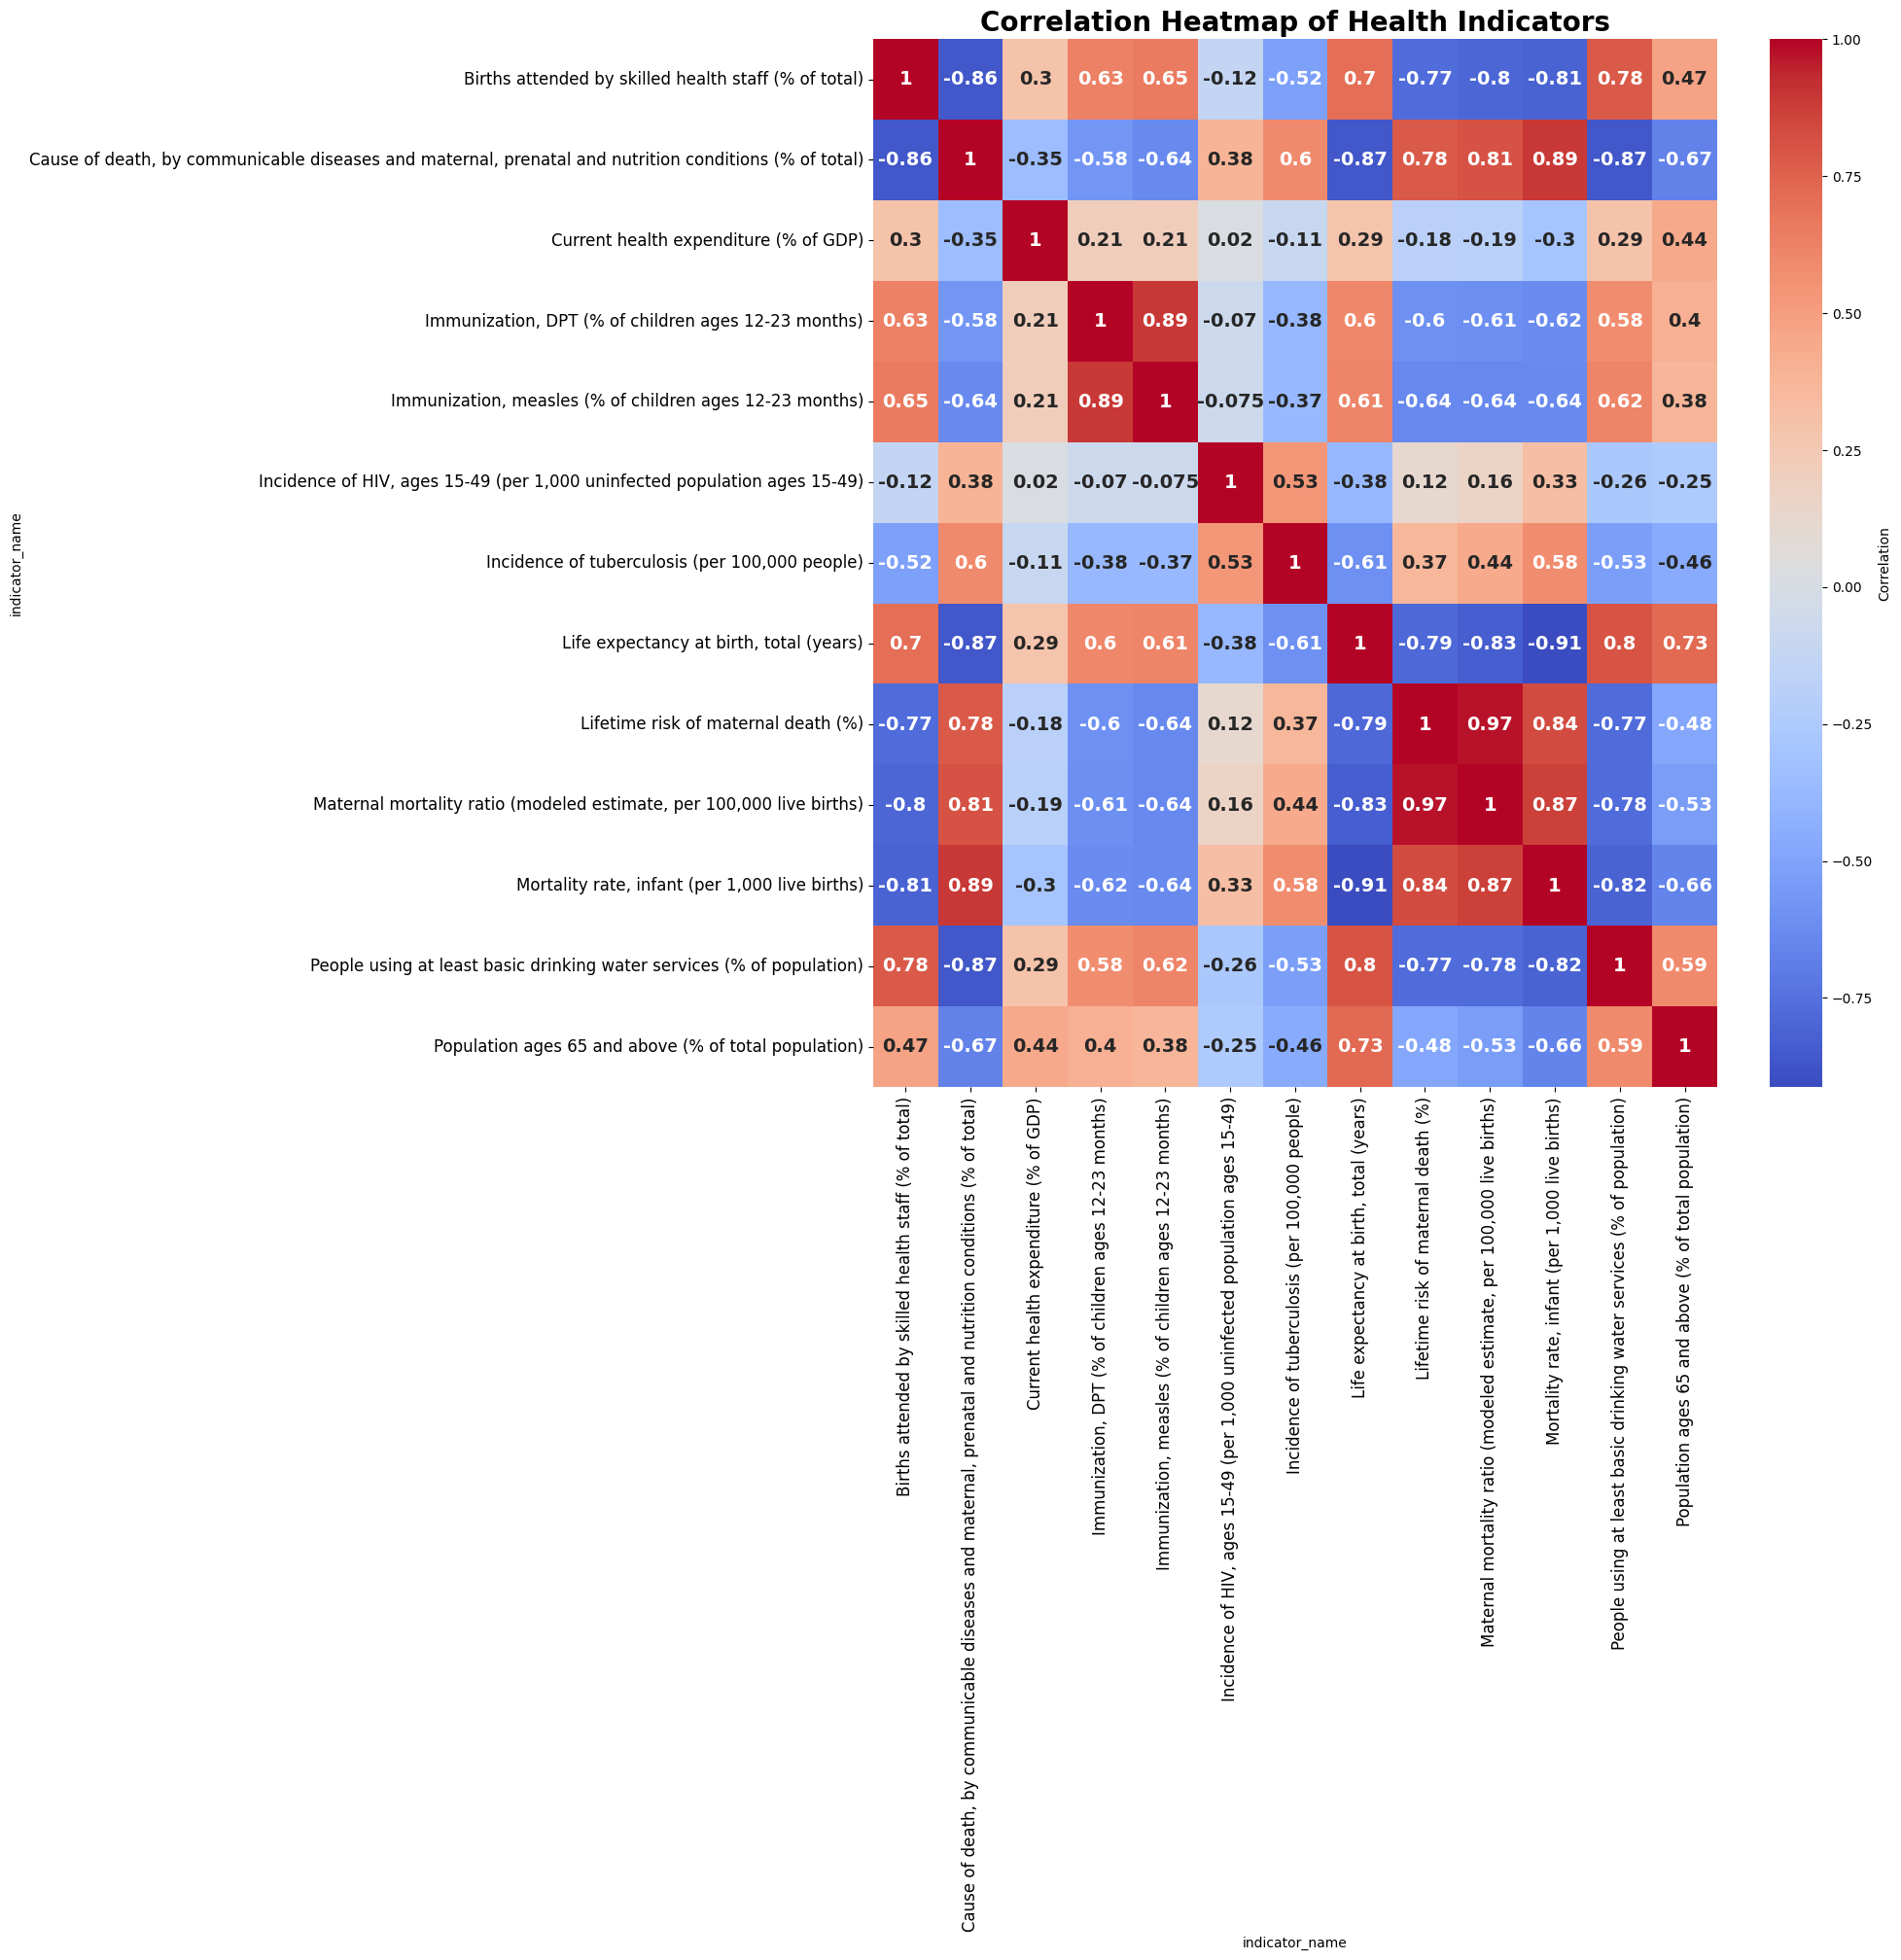

In [ ]:
df_wide = health.pivot_table(index = ["country_value", "year"], columns = "indicator_name", values = "value")

corr = df_wide.corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 14), facecolor="None")

ax = sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    cbar_kws= {"label": "Correlation"},
    annot_kws= {"fontsize": 14, "fontweight": "bold"}

)

plt.title("Correlation Heatmap of Health Indicators", fontsize=20, fontweight="bold")
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)


In [58]:
df_pivot = health.pivot_table(index = ["country_value", "year"], columns = "indicator_name", values = "value").reset_index()

In [59]:
df_pivot

indicator_name,country_value,year,Births attended by skilled health staff (% of total),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",Current health expenditure (% of GDP),"Immunization, DPT (% of children ages 12-23 months)","Immunization, measles (% of children ages 12-23 months)","Incidence of HIV, ages 15-49 (per 1,000 uninfected population ages 15-49)","Incidence of tuberculosis (per 100,000 people)","Life expectancy at birth, total (years)",Lifetime risk of maternal death (%),"Maternal mortality ratio (modeled estimate, per 100,000 live births)","Mortality rate, infant (per 1,000 live births)",People using at least basic drinking water services (% of population),Population ages 65 and above (% of total population)
0,Afghanistan,2016,NaN,NaN,11.818590,66.0,64.0,0.1,204.0,62.646,3.775891,702.0,62.3,62.822070,2.355497
1,Afghanistan,2017,53.4,NaN,12.620817,64.0,64.0,0.1,209.0,62.406,3.469739,659.0,60.4,65.142136,2.359737
2,Afghanistan,2018,58.8,NaN,14.208419,68.0,66.0,0.1,212.0,62.443,3.246425,629.0,58.6,67.475869,2.367120
3,Afghanistan,2019,NaN,32.930451,14.831320,65.0,57.0,0.1,213.0,62.941,3.042626,601.0,56.9,69.822698,2.376153
4,Afghanistan,2020,61.8,NaN,15.533614,61.0,57.0,0.1,205.0,61.454,3.135944,634.0,55.3,72.182071,2.370734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2380,Zimbabwe,2020,NaN,NaN,2.954401,86.0,85.0,1.9,189.0,61.530,1.407570,380.0,44.9,67.166424,3.581674
2381,Zimbabwe,2021,NaN,NaN,2.671119,88.0,88.0,2.2,198.0,60.135,1.632553,446.0,43.6,67.162605,3.597974
2382,Zimbabwe,2022,NaN,NaN,3.395195,90.0,90.0,1.6,209.0,62.360,1.346997,368.0,42.2,67.168908,3.608227
2383,Zimbabwe,2023,NaN,NaN,2.926016,90.0,90.0,1.5,209.0,62.775,1.288230,358.0,40.6,67.184919,3.618322


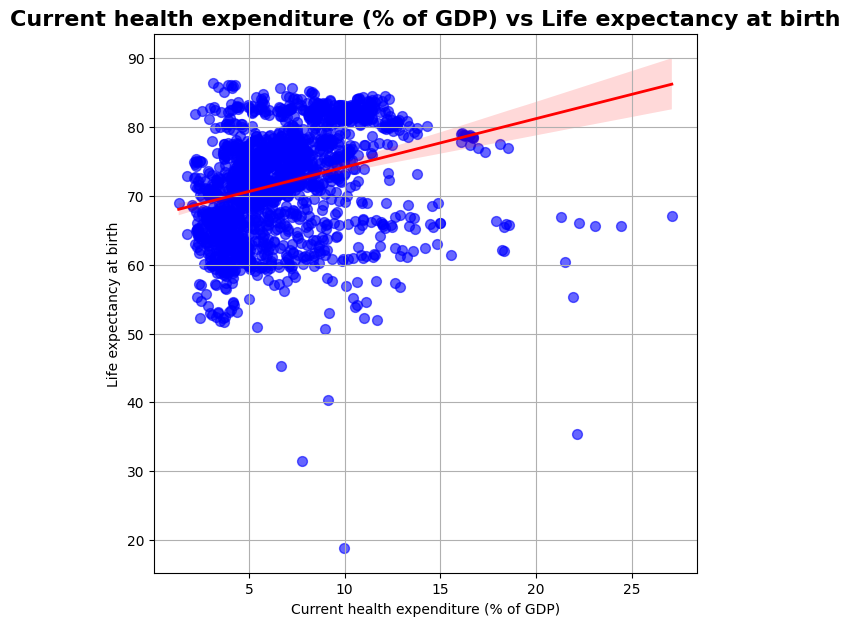

In [71]:
df_pivot = health.pivot_table(index = ["country_value", "year"], columns = "indicator_name", values = "value").reset_index()
plt.figure(figsize=(7, 7), facecolor="None")

ax = sns.regplot(data = df_pivot,
                x= "Current health expenditure (% of GDP)",
                y= "Life expectancy at birth, total (years)",
                scatter_kws={"s": 50, "color": "blue", "alpha": 0.6},
                line_kws={"color": "red", "lw": 2}
                )

plt.title("Current health expenditure (% of GDP) vs Life expectancy at birth", fontsize=16, fontweight="bold")
plt.xlabel("Current health expenditure (% of GDP)")
plt.ylabel("Life expectancy at birth")
plt.grid(True)
plt.show()